In [1]:
!pip install wfdb --quiet

import os, ast, random
import numpy as np
import pandas as pd
from tqdm import tqdm
from collections import Counter

from sklearn.utils import shuffle
import matplotlib.pyplot as plt
import wfdb

# REPRODUCIBILITY
SEED = 42
random.seed(SEED)
np.random.seed(SEED)

# ======= PATHS (KAGGLE) ========
BASE = "/kaggle/input/ecg-detection/ptbl_xl_large_dataset"

DB_CSV  = os.path.join(BASE, "ptbxl_database.csv")
SCP_CSV = os.path.join(BASE, "scp_statements.csv")

print(DB_CSV)
print(SCP_CSV)

# Load metadata + scp statements
db  = pd.read_csv(DB_CSV)
scp = pd.read_csv(SCP_CSV)


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 163.8/163.8 kB 6.1 MB/s eta 0:00:00
/kaggle/input/ecg-detection/ptbl_xl_large_dataset/ptbxl_database.csv
/kaggle/input/ecg-detection/ptbl_xl_large_dataset/scp_statements.csv


In [2]:
mi_codes = []

for c in scp["Unnamed: 0"].astype(str):
    u = c.upper()
    if any(k in u for k in [
        "MI","IMI","AMI","INFARCTION",
        "STEMI","NSTEMI","INFERIOR MI","ANTERIOR MI","POSTERIOR MI",
        "OLD MI","OMI","PMI","LMI"
    ]):
        mi_codes.append(c)

mi_codes = set(mi_codes)

print("CAD/MI codes:", len(mi_codes))

def parse_scp(x):
    try:
        return set(ast.literal_eval(x).keys())
    except:
        return set()

db["scp_set"] = db["scp_codes"].apply(parse_scp)

def map_label_2class(s):
    if "NORM" in s:
        return 0
    if len(s & mi_codes) > 0:
        return 1
    return None

db["label_2"] = db["scp_set"].apply(map_label_2class)

db2 = db.dropna(subset=["label_2"]).copy()
db2["label_2"] = db2["label_2"].astype(int)

print("Final 2-class distribution:", db2["label_2"].value_counts())


CAD/MI codes: 9
Final 2-class distribution: label_2
0    9514
1    5287
Name: count, dtype: int64


In [3]:
cnt = db2["label_2"].value_counts()
min_n = cnt.min()

idx_0 = db2[db2["label_2"]==0].sample(min_n, random_state=SEED).index
idx_1 = db2[db2["label_2"]==1].sample(min_n, random_state=SEED).index

db_bal = db2.loc[idx_0.union(idx_1)].sample(frac=1.0, random_state=SEED)

print(db_bal["label_2"].value_counts())


label_2
0    5287
1    5287
Name: count, dtype: int64


In [4]:
from scipy.signal import butter, filtfilt, resample

TARGET_FS = 500
TARGET_LEN = 5000
NUM_LEADS = 12

def butter_bandpass(low, high, fs, order=4):
    nyq = fs * 0.5
    return butter(order, [low/nyq, high/nyq], btype="band")

def clean_ecg(sig, fs):
    sig = np.nan_to_num(sig)

    if sig.shape[1] < 12:
        sig = np.pad(sig, ((0,0),(0,12-sig.shape[1])))
    else:
        sig = sig[:, :12]

    b,a = butter_bandpass(0.5,40,fs)

    cleaned = []
    for i in range(12):
        cleaned.append(filtfilt(b,a,sig[:,i]))
    cleaned = np.stack(cleaned,axis=1)

    new_len = int(cleaned.shape[0] * TARGET_FS / fs)
    cleaned = np.stack([resample(cleaned[:,i], new_len) for i in range(12)],axis=1)

    if cleaned.shape[0] > TARGET_LEN:
        start = (cleaned.shape[0]-TARGET_LEN)//2
        cleaned = cleaned[start:start+TARGET_LEN]
    else:
        pad = TARGET_LEN-cleaned.shape[0]
        cleaned = np.pad(cleaned,((pad//2,pad-pad//2),(0,0)))

    for i in range(12):
        std = cleaned[:,i].std()
        if std < 1e-6: return None
        cleaned[:,i]=(cleaned[:,i]-cleaned[:,i].mean())/(std+1e-8)

    return cleaned.astype(np.float32)


In [5]:
X_list = []
y_list = []

for _, row in tqdm(db_bal.iterrows(), total=len(db_bal)):
    fpath = os.path.join(BASE, row["filename_hr"]) if isinstance(row["filename_hr"], str) else os.path.join(BASE, row["filename"])

    try:
        rec = wfdb.rdrecord(fpath)
        sig = rec.p_signal
        fs  = rec.fs
    except:
        continue

    clean = clean_ecg(sig, fs)
    if clean is None:
        continue

    X_list.append(clean)
    y_list.append(row["label_2"])

X = np.array(X_list, dtype=np.float32)
y = np.array(y_list, dtype=np.int32)

print("Final X:", X.shape)
print("Final y:", Counter(y))

np.save("/kaggle/working/X_ptb_2class.npy", X)
np.save("/kaggle/working/y_ptb_2class.npy", y)


100%|██████████| 10574/10574 [03:45<00:00, 46.83it/s]


Final X: (10573, 5000, 12)
Final y: Counter({0: 5287, 1: 5286})


In [6]:
from sklearn.model_selection import train_test_split

X_temp, X_test, y_temp, y_test = train_test_split(
    X, y, test_size=0.15, stratify=y, random_state=SEED)

X_train, X_val, y_train, y_val = train_test_split(
    X_temp, y_temp, test_size=0.10, stratify=y_temp, random_state=SEED)

print("Train:", X_train.shape)
print("Val  :", X_val.shape)
print("Test :", X_test.shape)


Train: (8088, 5000, 12)
Val  : (899, 5000, 12)
Test : (1586, 5000, 12)


In [7]:
from scipy.stats import kurtosis, skew

def extract_features(signal12):

    feats = []
    for lead in range(12):
        x = signal12[:,lead]

        feats.append(np.mean(x))
        feats.append(np.std(x))
        feats.append(np.min(x))
        feats.append(np.max(x))
        feats.append(np.ptp(x))
        feats.append(np.sum(x**2))
        feats.append(np.mean(np.abs(np.diff(x))))
        feats.append(((x[:-1]*x[1:])<0).sum())
        feats.append(kurtosis(x))
        feats.append(skew(x))

    return np.array(feats)

# Extract ALL features
Xf = np.array([extract_features(x) for x in X])
yf = y.copy()

print("Feature matrix shape:", Xf.shape)


Feature matrix shape: (10573, 120)


In [8]:
X_train, X_test, y_train, y_test = train_test_split(
    Xf, yf,
    test_size=0.15,
    random_state=42,
    stratify=yf
)


In [9]:
from sklearn.ensemble import RandomForestClassifier

rf = RandomForestClassifier(
    n_estimators=400,
    max_depth=20,
    class_weight="balanced",
    random_state=42,
    n_jobs=-1
)

rf.fit(X_train, y_train)
print("Random Forest training complete!")


Random Forest training complete!



Accuracy: 0.8543505674653216

Classification Report:
               precision    recall  f1-score   support

           0       0.86      0.85      0.85       793
           1       0.85      0.86      0.85       793

    accuracy                           0.85      1586
   macro avg       0.85      0.85      0.85      1586
weighted avg       0.85      0.85      0.85      1586



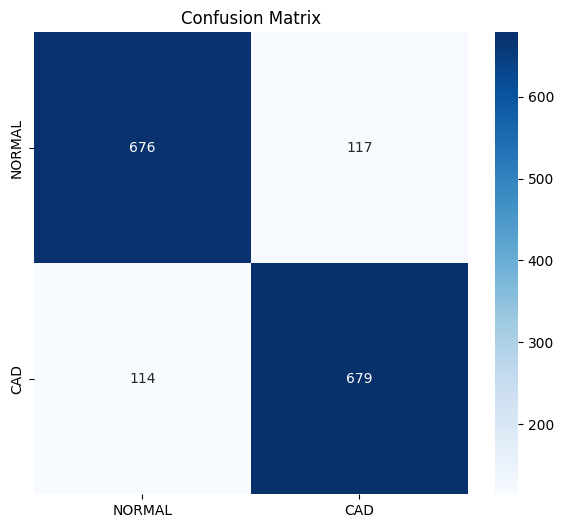

In [10]:
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score
import seaborn as sns

y_pred = rf.predict(X_test)

print("\nAccuracy:", accuracy_score(y_test, y_pred))
print("\nClassification Report:\n", classification_report(y_test, y_pred))

cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(7,6))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
            xticklabels=["NORMAL","CAD"],
            yticklabels=["NORMAL","CAD"])
plt.title("Confusion Matrix")
plt.show()


In [11]:
import joblib
joblib.dump(rf, "/kaggle/working/random_forest_ecg.pkl")

print("Saved model: /kaggle/working/random_forest_ecg.pkl")


Saved model: /kaggle/working/random_forest_ecg.pkl


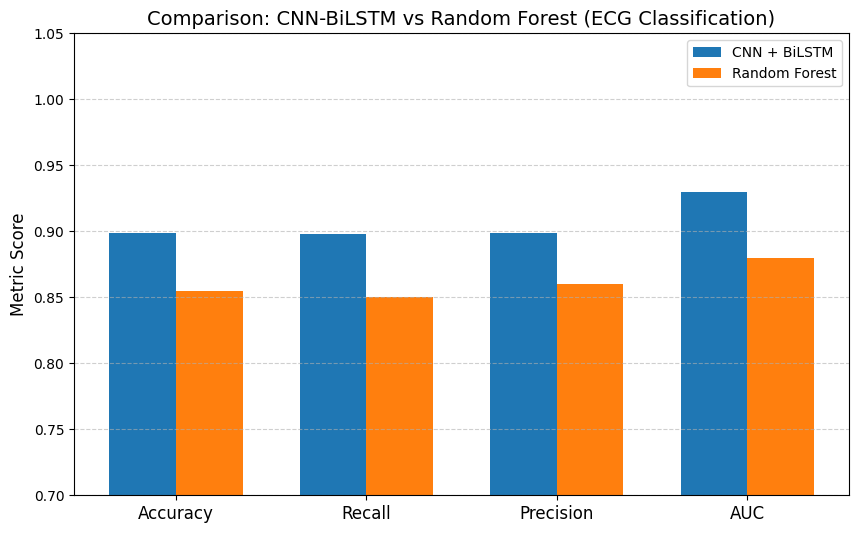

In [12]:
import matplotlib.pyplot as plt
import numpy as np

# ==== MODEL METRICS ====

# CNN + BiLSTM
cnn_acc = 0.8985
cnn_prec = 0.899
cnn_rec = 0.898
cnn_auc = 0.93

# Random Forest
rf_acc = 0.855
rf_prec = 0.86
rf_rec = 0.85
rf_auc = 0.88

# Convert to arrays
cnn_vals = [cnn_acc, cnn_rec, cnn_prec, cnn_auc]
rf_vals  = [rf_acc,  rf_rec,  rf_prec,  rf_auc ]

labels = ["Accuracy", "Recall", "Precision", "AUC"]

x = np.arange(len(labels))
width = 0.35

# ==== PLOT ====
plt.figure(figsize=(10,6))
plt.bar(x - width/2, cnn_vals, width, label="CNN + BiLSTM", color="#1f77b4")
plt.bar(x + width/2, rf_vals,  width, label="Random Forest", color="#ff7f0e")

plt.xticks(x, labels, fontsize=12)
plt.ylabel("Metric Score", fontsize=12)
plt.ylim(0.7, 1.05)
plt.title("Comparison: CNN-BiLSTM vs Random Forest (ECG Classification)", fontsize=14)
plt.legend()

# Show grid lines
plt.grid(axis='y', linestyle='--', alpha=0.6)

plt.show()


In [14]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import KFold
from sklearn.metrics import accuracy_score
import numpy as np


In [15]:
kf = KFold(n_splits=10, shuffle=True, random_state=42)
fold_scores = []

fold = 1
for train_index, val_index in kf.split(Xf):

    print(f"\n===== Fold {fold} =====")

    X_tr, X_val = Xf[train_index], Xf[val_index]
    y_tr, y_val = yf[train_index], yf[val_index]

    # ----- NEW MODEL EACH FOLD -----
    rf = RandomForestClassifier(
        n_estimators=300,
        max_depth=20,
        random_state=42,
        n_jobs=-1
    )

    rf.fit(X_tr, y_tr)

    y_pred = rf.predict(X_val)
    acc = accuracy_score(y_val, y_pred)

    print(f"Fold {fold} Accuracy: {acc*100:.2f}%")
    fold_scores.append(acc * 100)

    fold += 1

mean_acc = np.mean(fold_scores)
print("\nAll Folds:", fold_scores)
print("Mean Accuracy:", mean_acc)



===== Fold 1 =====
Fold 1 Accuracy: 86.11%

===== Fold 2 =====
Fold 2 Accuracy: 85.63%

===== Fold 3 =====
Fold 3 Accuracy: 83.18%

===== Fold 4 =====
Fold 4 Accuracy: 82.78%

===== Fold 5 =====
Fold 5 Accuracy: 85.81%

===== Fold 6 =====
Fold 6 Accuracy: 85.90%

===== Fold 7 =====
Fold 7 Accuracy: 85.05%

===== Fold 8 =====
Fold 8 Accuracy: 83.82%

===== Fold 9 =====
Fold 9 Accuracy: 83.07%

===== Fold 10 =====
Fold 10 Accuracy: 83.16%

All Folds: [86.10586011342156, 85.63327032136105, 83.1758034026465, 82.78145695364239, 85.80889309366131, 85.9035004730369, 85.05203405865657, 83.8221381267739, 83.06527909176916, 83.15988647114474]
Mean Accuracy: 84.45081221061142


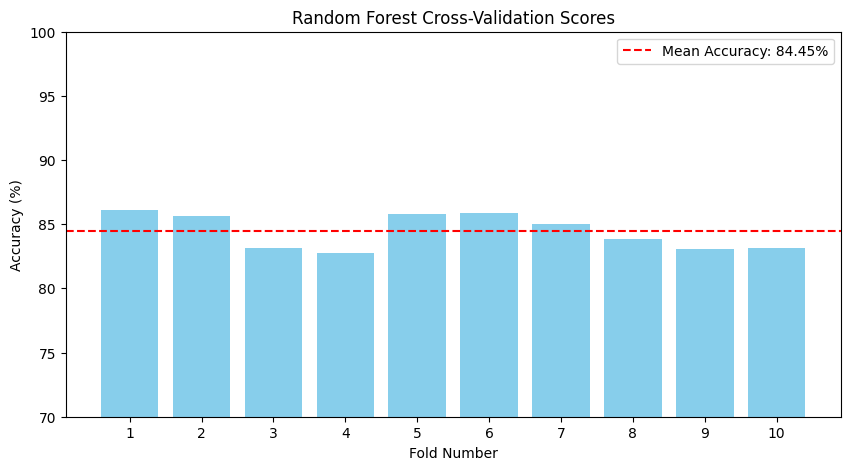

In [16]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10,5))
plt.bar(range(1,11), fold_scores, color="skyblue")

plt.axhline(np.mean(fold_scores), color="red", linestyle="--",
            label=f"Mean Accuracy: {np.mean(fold_scores):.2f}%")

plt.xticks(range(1,11))
plt.ylim(70, 100)
plt.xlabel("Fold Number")
plt.ylabel("Accuracy (%)")
plt.title("Random Forest Cross-Validation Scores")
plt.legend()
plt.show()
